In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal
import time
import os
import sys
import json

import pickle

sns.set_context("talk",rc={"font.size":15,"axes.titlesize":15,"axes.labelsize":15})
sns.set_style("whitegrid",{"grid.color": '.9', 'grid.linestyle': '--','axes.edgecolor': '.6', 'xtick.bottom': True,'ytick.left': True})

colorTable = {}
colorTable['k'] = [0,0,0]
colorTable['g'] = [27/255,158/255,119/255]
colorTable['o'] = [217/255,95/255,2/255]
colorTable["p"] = [117/255,112/255,179/255]

from itertools import product

import pandas as pd

import overlappingGenes as og

# Precompute codon table as a dict
CODON_TABLE = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

def revcomp(seq):
    """Return the reverse complement of a nucleotide sequence string."""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    return ''.join(comp[b] for b in reversed(seq))

def get_codons_for_aa(aa):
    """Get all codons that encode a given amino acid."""
    return [codon for codon, amino_acid in CODON_TABLE.items() if amino_acid == aa]

def get_params_and_stats(pf_name):
    if pf_name in PARAMS_CACHE:
        return PARAMS_CACHE[pf_name], NATURAL_STATS_CACHE[pf_name]
    param_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_params.dat")
    J, h = og.extract_params(param_file)
    PARAMS_CACHE[pf_name] = [J, h]
    nat_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_naturalenergies.txt")
    energies = og.load_natural_energies(nat_file)
    NATURAL_STATS_CACHE[pf_name] = (np.mean(energies), np.std(energies))
    return [J, h], (np.mean(energies), np.std(energies))


# Add current directory to path to import overlappingGenes
sys.path.append(os.getcwd())

BASE_DIR = "../0 bmDCA"
OPTIMAL_TEMPS_FILE = "optimal_temperatures.json"

ITERATIONS = 999_999
N_TRIALS = 30

# --- Load protein families ---
ALL_PF_DIRS = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
print(f"Found {len(ALL_PF_DIRS)} Protein Families: {ALL_PF_DIRS}")

# --- Load optimal temperatures ---
if os.path.exists(OPTIMAL_TEMPS_FILE):
    with open(OPTIMAL_TEMPS_FILE, 'r') as f:
        OPTIMAL_TEMPS = json.load(f)
else:
    OPTIMAL_TEMPS = {}

# Precompute params and stats for all PFs (to avoid repeated file IO in workers)
PARAMS_CACHE = {}
NATURAL_STATS_CACHE = {}
for pf in ALL_PF_DIRS:
    params, stats = get_params_and_stats(pf)
    PARAMS_CACHE[pf] = params
    NATURAL_STATS_CACHE[pf] = stats

Found 2 Protein Families: ['PF00009', 'PF00072']


## Generate sequences

In [2]:
# Let's record 20 sequences at max overlap
pf1      = "PF00072"
pf2      = "PF00009"
overlap  = 317 # 317 is longest -2, 211 is potentially interesting Frame -1

ntrial = 50 #300
numiterations = 1_000_000

params1, (nat_mean1, nat_std1) = PARAMS_CACHE[pf1], NATURAL_STATS_CACHE[pf1]
params2, (nat_mean2, nat_std2) = PARAMS_CACHE[pf2], NATURAL_STATS_CACHE[pf2]
t1 = float(OPTIMAL_TEMPS.get(pf1, 1.0))
t2 = float(OPTIMAL_TEMPS.get(pf2, 1.0))
len1 = len(params1[1]) // 21
len2 = len(params2[1]) // 21


# Length of sequence 1
hvec = params1[1]
len1 = len(hvec) / 21
print(f"Length of sequence 1: {len1} amino acids or 3 x {len1*3} nucleotides")

# Length of sequence 2
hvec = params2[1]
len2 = len(hvec) / 21
print(f"Length of sequence 2: {len2} amino acids or 3 x {len2*3} nucleotides")

# Lengths in nucleotides
l1_nt = int(3*len1) # exclude stop
l2_nt = int(3*len2) # exclude stop

best_seqs = []
best_energies_1 = []
best_energies_2 = []
for tr in range(ntrial):
    init_seq = og.initial_seq_no_stops(len1, len2, overlap, quiet=True)
    result = og.overlapped_sequence_generator_int(
        params1, params2, init_seq,
        numberofiterations=numiterations,
        whentosave=.01,
        quiet=False,
        T1=0.65, T2=0.6,
        nat_mean1=nat_mean1, nat_mean2=nat_mean2,
        std_mean1=nat_std1, std_mean2=nat_std2
    )

    final_seq = result[0]
    accepted = result[1]
    energy_history_seq1 = result[2]
    energy_history_seq2 = result[3]
    final_energies = result[4]
    best_energies = result[5]
    best_seq = result[6]
    best_save_idx = result[7]

    best_seqs.append(best_seq)
    best_energies_1.append(best_energies[0])
    best_energies_2.append(best_energies[1])

    print(f"Trial {tr+1}/{ntrial} completed. Best energies: {best_energies[0]:.2f}, {best_energies[1]:.2f}")


Length of sequence 1: 108.0 amino acids or 3 x 324.0 nucleotides
Length of sequence 2: 162.0 amino acids or 3 x 486.0 nucleotides
Trial 1/50 completed. Best energies: 201.34, 184.99
Trial 2/50 completed. Best energies: 201.31, 185.21
Trial 3/50 completed. Best energies: 201.34, 185.09
Trial 4/50 completed. Best energies: 201.35, 185.01
Trial 5/50 completed. Best energies: 201.40, 185.09
Trial 6/50 completed. Best energies: 201.36, 184.96
Trial 7/50 completed. Best energies: 201.32, 185.06
Trial 8/50 completed. Best energies: 201.37, 185.08
Trial 9/50 completed. Best energies: 201.42, 185.00
Trial 10/50 completed. Best energies: 201.36, 185.02
Trial 11/50 completed. Best energies: 201.42, 185.12
Trial 12/50 completed. Best energies: 201.39, 184.98
Trial 13/50 completed. Best energies: 201.15, 195.84
Trial 14/50 completed. Best energies: 201.22, 185.11
Trial 15/50 completed. Best energies: 201.34, 185.06
Trial 16/50 completed. Best energies: 201.37, 185.06
Trial 17/50 completed. Best ene

In [3]:
# Save sequences and energies to a pickle file
output_data = {
    'best_seqs': best_seqs,
    'best_energies_1': best_energies_1,
    'best_energies_2': best_energies_2
}
with open(f'Pickles/20260330_{pf1}_{pf2}_{overlap}_{ntrial}Sequences_longerrun.pkl', 'wb') as f:
    pickle.dump(output_data, f)

# Load sequences and continue

In [2]:
# Let's record 20 sequences at max overlap
pf1      = "PF00072"
pf2      = "PF00009"
overlap  = 317 # 317 is longest -2, 211 is potentially interesting Frame -1

params1, (nat_mean1, nat_std1) = PARAMS_CACHE[pf1], NATURAL_STATS_CACHE[pf1]
params2, (nat_mean2, nat_std2) = PARAMS_CACHE[pf2], NATURAL_STATS_CACHE[pf2]

# # Load data from pickle file
# with open(f'Pickles/20260327_{pf1}_{pf2}_{overlap}_SomeSequences.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)

# Load data from pickle file
with open(f'Pickles/20260330_{pf1}_{pf2}_{overlap}_50Sequences_longerrun.pkl', 'rb') as f:
    loaded_data = pickle.load(f)


best_seqs, best_energies_1, best_energies_2 = loaded_data['best_seqs'], loaded_data['best_energies_1'], loaded_data['best_energies_2']

Mean z-score for sequence 1: 0.00 ± 0.00
Mean z-score for sequence 2: 0.01 ± 0.06


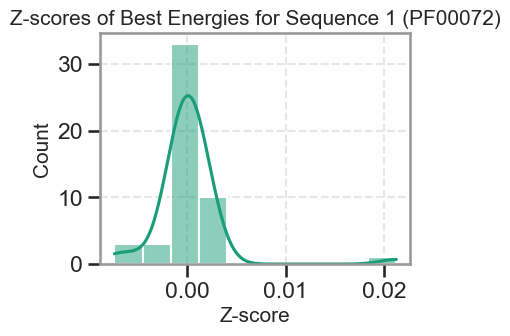

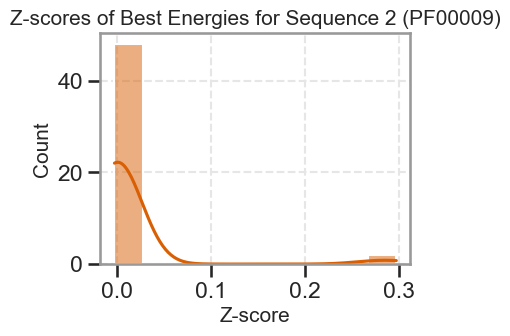

In [3]:
# Plot histogram of z-scores for best energies of sequence 1
z_scores_1 = [(e - nat_mean1) / nat_std1 for e in best_energies_1]
plt.figure(figsize=(4, 3))
sns.histplot(z_scores_1, bins=10, kde=True, color=colorTable['g'])
plt.title(f"Z-scores of Best Energies for Sequence 1 ({pf1})")
plt.xlabel("Z-score")
plt.ylabel("Count")
print(f"Mean z-score for sequence 1: {np.mean(z_scores_1):.2f} ± {np.std(z_scores_1):.2f}")

# Plot histogram of z-scores for best energies of sequence 2
z_scores_2 = [(e - nat_mean2) / nat_std2 for e in best_energies_2]
plt.figure(figsize=(4, 3))
sns.histplot(z_scores_2, bins=10, kde=True, color=colorTable['o'])
plt.title(f"Z-scores of Best Energies for Sequence 2 ({pf2})")
plt.xlabel("Z-score")
plt.ylabel("Count")
print(f"Mean z-score for sequence 2: {np.mean(z_scores_2):.2f} ± {np.std(z_scores_2):.2f}")

Mean pairwise hamming distance: 159.9 ± 12.7 out of 499 nt
Max hamming distance: 201 between sequences 8 and 30
Top 10 pairs with highest hamming distance:
Pair 1: Sequences 8 and 30 with hamming distance 201
Pair 2: Sequences 8 and 29 with hamming distance 198
Pair 3: Sequences 8 and 23 with hamming distance 194
Pair 4: Sequences 40 and 41 with hamming distance 193
Pair 5: Sequences 8 and 41 with hamming distance 192
Pair 6: Sequences 17 and 39 with hamming distance 191
Pair 7: Sequences 41 and 44 with hamming distance 190
Pair 8: Sequences 24 and 41 with hamming distance 190
Pair 9: Sequences 14 and 23 with hamming distance 190
Pair 10: Sequences 11 and 39 with hamming distance 190


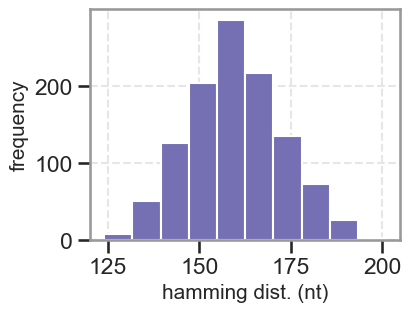

In [4]:
# Filter best sequences so that |z| < 0.25 for both energies
filtered_seqs = []
for seq, e1, e2 in zip(best_seqs, best_energies_1, best_energies_2):
    z1 = (e1 - nat_mean1) / nat_std1
    z2 = (e2 - nat_mean2) / nat_std2
    if abs(z1) < 0.25 and abs(z2) < 0.25:
        filtered_seqs.append(seq)

# Plot pairwise hamming distances between best sequences
plt.figure(figsize=(4, 3))
hams = []
for i in range(len(filtered_seqs)):
    for j in range(i+1, len(filtered_seqs)):
        seq1 = filtered_seqs[i]
        seq2 = filtered_seqs[j]
        hamming_distance = sum(c1 != c2 for c1, c2 in zip(seq1, seq2))
        hams.append(hamming_distance)

plt.hist(hams, bins=10, color=colorTable['p'])
plt.ylabel("frequency")
plt.xlabel("hamming dist. (nt)")

totalseqlength = len(filtered_seqs[0])
print(f"Mean pairwise hamming distance: {np.mean(hams):.1f} ± {np.std(hams):.1f} out of {totalseqlength} nt")

# Find pair with max hamming distance
max_ham = 0
max_pair = (0, 0)
for i in range(len(filtered_seqs)):
    for j in range(i+1, len(filtered_seqs)):
        seq1 = filtered_seqs[i]
        seq2 = filtered_seqs[j]
        hamming_distance = sum(c1 != c2 for c1, c2 in zip(seq1, seq2))
        if hamming_distance > max_ham:
            max_ham = hamming_distance
            max_pair = (i, j)

print(f"Max hamming distance: {max_ham} between sequences {max_pair[0]} and {max_pair[1]}")

# Return top ten pairs with highest hamming distance
ham_pairs = []
for i in range(len(filtered_seqs)):
    for j in range(i+1, len(filtered_seqs)):
        seq1 = filtered_seqs[i]
        seq2 = filtered_seqs[j]
        hamming_distance = sum(c1 != c2 for c1, c2 in zip(seq1, seq2))
        ham_pairs.append((hamming_distance, i, j))

ham_pairs.sort(reverse=True)
print("Top 10 pairs with highest hamming distance:")
for k in range(min(10, len(ham_pairs))):
    print(f"Pair {k+1}: Sequences {ham_pairs[k][1]} and {ham_pairs[k][2]} with hamming distance {ham_pairs[k][0]}")

## Genetic Algorithm

In [12]:
from ga_worker_fast import GeneticPathFinderFast, get_path_energies_separate_fast
import ga_worker as ga
from overlappingGenes import seq_str_to_int_array

# GA parameters
Z_SCORE = True
GA_POPULATION = 100
GA_GENERATIONS = 300

# Unpack params
Jvec1, hvec1 = params1[0], params1[1]
Jvec2, hvec2 = params2[0], params2[1]

# Lengths in nucleotides
len_seq_1_n = int(3 * len(hvec1) / 21 + 3)
len_seq_2_n = int(3 * len(hvec2) / 21 + 3)

# Lengths in AA (including stop)
len_aa_1 = len_seq_1_n // 3
len_aa_2 = len_seq_2_n // 3

def find_paths(seq_start, seq_end, returnSummary = False):
    mut_positions, mut_old_nts, mut_new_nts = ga.get_mutations_arrays(seq_start, seq_end)

    seq_arr = ga.seq_to_array(seq_start)
    galg = GeneticPathFinderFast(
        seq_start, seq_end,
        Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2,
        nat_mean_1=nat_mean1, nat_mean_2=nat_mean2,
        nat_std_1=nat_std1, nat_std_2=nat_std2, z_score=Z_SCORE,
        pop_size=GA_POPULATION, n_generations=GA_GENERATIONS
    )
    initial_pop = galg.initialize_population()
    initial_e1_paths = []
    initial_e2_paths = []
    for i in range(min(20, len(initial_pop))):
        e1, e2 = get_path_energies_separate_fast(
            initial_pop[i], seq_arr, mut_positions, mut_new_nts,
            Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2)
        initial_e1_paths.append(e1)
        initial_e2_paths.append(e2)
        
    best_order, max_distance, path_energies_combined, path_distances = galg.run(verbose=True)
    best_order_arr = np.array(best_order, dtype=np.int32)

    evolved_e1, evolved_e2 = get_path_energies_separate_fast(
        best_order_arr, seq_arr, mut_positions, mut_new_nts,
        Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2)
    
    if returnSummary:
        # For each pair, find the highest energy along the path and plot histogram of these max energies for sequence 1 and sequence 2 separately
        max_e1_paths = [(max(path) - nat_mean1)/nat_std1 for path in initial_e1_paths]
        max_e2_paths = [(max(path) - nat_mean2)/nat_std2 for path in initial_e2_paths]

        # Repeat for evolved paths
        max_evolved_e1 = (max(evolved_e1) - nat_mean1)/nat_std1
        max_evolved_e2 = (max(evolved_e2) - nat_mean2)/nat_std2

        return max_e1_paths, max_e2_paths, max_evolved_e1, max_evolved_e2
    else:
        return initial_e1_paths, initial_e2_paths, evolved_e1, evolved_e2

In [8]:
# Run GA on the pair with max hamming distance to see if we can connect them
seq_start = filtered_seqs[ham_pairs[0][1]]
seq_end = filtered_seqs[ham_pairs[0][2]]

initial_e1_paths, initial_e2_paths, evolved_e1, evolved_e2 = find_paths(seq_start, seq_end)

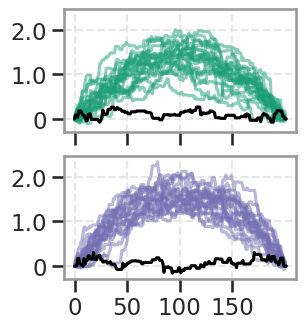

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(3, 3.5), sharey=True, sharex=True)

for e1 in initial_e1_paths:
    z1 = (e1 - nat_mean1)/nat_std1
    axs[0].plot(z1, color = colorTable["g"], alpha = 0.5)
    # print(z1[0])

z1 = (evolved_e1 - nat_mean1)/nat_std1
axs[0].plot(z1, color = "k", alpha = 1)

for e2 in initial_e2_paths:
    z2 = (e2 - nat_mean2)/nat_std2
    axs[1].plot(z2, color = colorTable["p"], alpha = 0.5)

z2 = (evolved_e2 - nat_mean2)/nat_std2
axs[1].plot(z2, color = "k", alpha = 1)

# Put y-axis marks at z = 0, 0.5, 1.0, 1.5, 2.0
axs[0].set_yticks([0, 1.0, 2.0])
axs[0].set_yticklabels([0, 1.0, 2.0])

axs[1].set_xticks([0, 50, 100,150])
axs[1].set_xticklabels([0, 50, 100,150])

# plt.tight_layout()
plt.savefig(f"Panels/20260328_{pf1}_{pf2}_{overlap}_GAPath_example.svg", dpi=300)

In [ ]:
# Pick ten first sequences from filtered_seqs
filtered_seqs_subset = filtered_seqs

max_e1_paths = []
max_e2_paths = []
max_evolved_e1 = []
max_evolved_e2 = []
for i in range(len(filtered_seqs_subset)):
    for j in range(i+1, len(filtered_seqs_subset)):
        seq1 = filtered_seqs_subset[i]
        seq2 = filtered_seqs_subset[j]

        thismax_e1_paths, thismax_e2_paths, thismax_evolved_e1, thismax_evolved_e2 = find_paths(seq1, seq2, returnSummary=True)
        max_e1_paths.extend(thismax_e1_paths)
        max_e2_paths.extend(thismax_e2_paths)
        max_evolved_e1.append(thismax_evolved_e1)
        max_evolved_e2.append(thismax_evolved_e2)

        # initial_e1_paths, initial_e2_paths, evolved_e1, evolved_e2 = find_paths(seq1, seq2)
        # initial_e1_paths_all.extend(initial_e1_paths)
        # initial_e2_paths_all.extend(initial_e2_paths)
        # evolved_e1_all.append(evolved_e1)
        # evolved_e2_all.append(evolved_e2)

        print(f"Completed GA for pair ({i}, {j})")

Completed GA for pair (0, 1)
Completed GA for pair (0, 2)
Completed GA for pair (0, 3)
Completed GA for pair (0, 4)
Completed GA for pair (0, 5)
Completed GA for pair (0, 6)
Completed GA for pair (0, 7)
Completed GA for pair (0, 8)
Completed GA for pair (0, 9)
Completed GA for pair (0, 10)
Completed GA for pair (0, 11)
Completed GA for pair (0, 12)
Completed GA for pair (0, 13)
Completed GA for pair (0, 14)
Completed GA for pair (0, 15)
Completed GA for pair (0, 16)
Completed GA for pair (0, 17)
Completed GA for pair (0, 18)
Completed GA for pair (0, 19)
Completed GA for pair (0, 20)
Completed GA for pair (0, 21)
Completed GA for pair (0, 22)
Completed GA for pair (0, 23)
Completed GA for pair (0, 24)
Completed GA for pair (0, 25)
Completed GA for pair (0, 26)
Completed GA for pair (0, 27)
Completed GA for pair (0, 28)
Completed GA for pair (0, 29)
Completed GA for pair (0, 30)
Completed GA for pair (0, 31)
Completed GA for pair (0, 32)
Completed GA for pair (0, 33)
Completed GA for pa

In [ ]:
# Save filtered sequences and their GA results to a pickle file
output_data = {
    'filtered_seqs': filtered_seqs_subset,
    'max_e1_paths': max_e1_paths,
    'max_e2_paths': max_e2_paths,
    'max_evolved_e1': max_evolved_e1,
    'max_evolved_e2': max_evolved_e2,
}

with open(f'Pickles/20260330_GA_{pf1}_{pf2}_{overlap}_{ntrial}Sequences_longerrun.pkl', 'wb') as f:
    pickle.dump(output_data, f)

In [6]:
# Load GA results from pickle file
with open(f'Pickles/20260330_GA_{pf1}_{pf2}_{overlap}_50Sequences_longerrun.pkl', 'rb') as f:
    loaded_ga_data = pickle.load(f)

filtered_seqs_subset = loaded_ga_data['filtered_seqs']
max_e1_paths = loaded_ga_data['max_e1_paths']
max_e2_paths = loaded_ga_data['max_e2_paths']
max_evolved_e1 = loaded_ga_data['max_evolved_e1']
max_evolved_e2 = loaded_ga_data['max_evolved_e2']

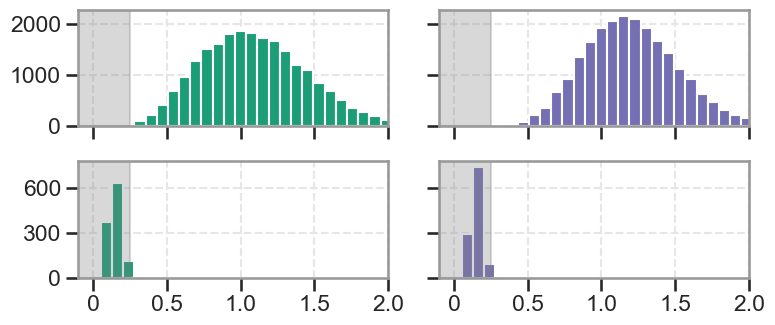

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(8, 3.5), sharex = True, sharey="row")
histbins = np.linspace(-.1, 2.1, 30)
# histbins = np.logspace(-1.5,1, 20)

# For each pair, find the highest energy along the path and plot histogram of these max energies for sequence 1 and sequence 2 separately
# max_e1_paths = [(max(path) - nat_mean1)/nat_std1 for path in initial_e1_paths_all]
# max_e2_paths = [(max(path) - nat_mean2)/nat_std2 for path in initial_e2_paths_all]

axs[0,0].hist(max_e1_paths, bins=histbins, color=colorTable['g'])
# axs[0,0].set_ylabel("Count")

axs[0,1].hist(max_e2_paths, bins=histbins, color=colorTable['p'])

# Repeat for evolved paths
# max_evolved_e1 = [(max(path) - nat_mean1)/nat_std1 for path in evolved_e1_all]
# max_evolved_e2 = [(max(path) - nat_mean2)/nat_std2 for path in evolved_e2_all]

axs[1,0].hist(max_evolved_e1, bins=histbins, color=colorTable['g'])
# axs[1,0].set_xlabel("Energy")
# axs[1,0].set_ylabel("counts")

axs[1,1].hist(max_evolved_e2, bins=histbins, color=colorTable['p'])
# axs[1,1].set_xlabel("Energy")

axs[0,0].set_yticks([0,1000,2000])
axs[1,1].set_yticks([0,300,600])

for x in range(2):
    for y in range(2):
        # Plot a vertical shaded region for z < zthresh
        zthresh = 0.25
        axs[x,y].axvspan(-zthresh, zthresh, color='gray', alpha=0.3)
        axs[x,y].set_xlim(-0.1, 2)
        # Set ticks to be at 0, 0.5, 1.0, 1.5, 2.0
        axs[x,y].set_xticks([0, 0.5, 1.0, 1.5, 2.0])
        axs[x,y].set_xticklabels([0, 0.5, 1.0, 1.5, 2.0])


# plt.xscale("log")
plt.tight_layout()
plt.savefig(f"Panels/20260330_{pf1}_{pf2}_{overlap}_max_height_histograms.svg", dpi=300)

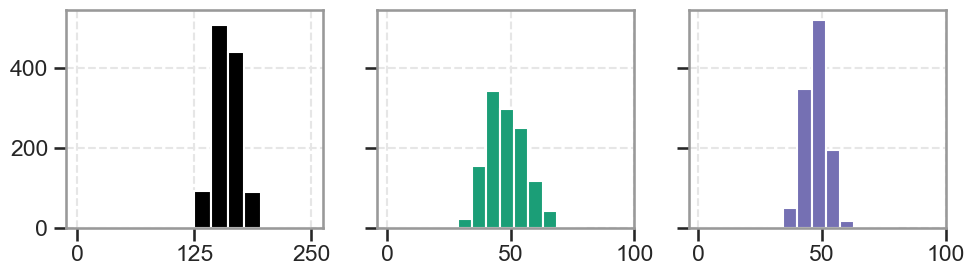

In [13]:
# Plot pairwise hamming distances between best sequences
# plt.figure(figsize=(4, 3))
hams = []
for i in range(len(filtered_seqs)):
    for j in range(i+1, len(filtered_seqs)):
        seq1 = filtered_seqs[i]
        seq2 = filtered_seqs[j]
        hamming_distance = sum(c1 != c2 for c1, c2 in zip(seq1, seq2))
        hams.append(hamming_distance)

# plt.hist(hams, bins=np.linspace(0,len(best_seqs[0]),40), color=colorTable['k'])
# plt.xticks(np.arange(0, len(best_seqs[0])+2, 100))


seq1aa_list = []
seq2aa_list = []
for thisseq in best_seqs:
    # thisseq = best_seqs[0]
    seq1 = thisseq[:len_seq_1_n]

    seq1aa = "".join([CODON_TABLE[seq1[i:i+3]] for i in range(0, len(seq1), 3)])[:-1] # exclude stop codon
    seq1aa_list.append(seq1aa)

    thisseqrev = revcomp(thisseq)
    seq2 = thisseqrev[:len_seq_2_n]

    seq2aa = "".join([CODON_TABLE[seq2[i:i+3]] for i in range(0, len(seq2), 3)])[:-1] # exclude stop codon
    seq2aa_list.append(seq2aa)

# Compute pairwise hamming distances between seq1 aa sequences
num_seqs = len(seq1aa_list)
ham1 = []
ham2 = []
for i in range(num_seqs):
    for j in range(i+1, num_seqs):
        thisham1 = sum(a != b for a, b in zip(seq1aa_list[i], seq1aa_list[j]))
        thisham2 = sum(a != b for a, b in zip(seq2aa_list[i], seq2aa_list[j]))
        ham1.append(thisham1)
        ham2.append(thisham2)

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

axs[0].hist(hams, bins=np.linspace(0,250,15), color=colorTable['k'])
axs[0].set_xticks([0, 125, 250])
# axs[0].set_yticks([0, 5, 10, 15, 20, 25])

axs[1].hist(ham1, bins=np.linspace(0, 80, 15), color=colorTable['g'])
axs[1].set_xticks([0, 50, 100])

axs[2].hist(ham2, bins=np.linspace(0, 80, 15), color=colorTable['p'])
axs[2].set_xticks([0, 50, 100])

plt.tight_layout()
plt.savefig(f"Panels/20260330_{pf1}_{pf2}_{overlap}_hamming_histograms.svg", dpi=300)

In [17]:
print(np.mean(hams), np.std(hams))

159.8758865248227 12.67874415279715
